RoBERTa + Bottleneck Layer + Focal Loss.

Bước 1: Khởi tạo môi trường, cài đặt thư viện Augmentation và kết nối GPU.

In [ ]:
!pip install transformers tensorflow pandas scikit-learn

In [ ]:
# ==============================================================================
# 1. KHAI BÁO THƯ VIỆN & CẤU HÌNH GPU (Standard Setup)
# ==============================================================================
# Cài đặt thư viện (Chỉ chạy 1 lần)
!pip install transformers tf-keras nlpaug

import pandas as pd
import numpy as np
import tensorflow as tf
import re
import os
from transformers import RobertaTokenizer, TFRobertaModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, accuracy_score
from google.colab import drive

# Kết nối Drive
drive.mount('/content/drive')

# Kiểm tra GPU (Để chắc chắn đang chạy nhanh)
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Bước 2: TIỀN XỬ LÝ & MÃ HÓA DỮ LIỆU (DATA PREPROCESSING)

In [ ]:
# ==============================================================================
# 2. TIỀN XỬ LÝ & MÃ HÓA DỮ LIỆU (DATA PREPROCESSING)
# ==============================================================================
# Cấu hình
DATA_PATH = 'mbti_1.csv'
MAX_LEN = 256
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

def clean_text(text):
    """Làm sạch văn bản: Xóa URL, ký tự lạ và ĐẶC BIỆT LÀ XÓA MÃ MBTI (Anti-Cheating)"""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Danh sách từ cấm (Tránh rò rỉ dữ liệu)
    mbti_types = ['infj', 'intp', 'infp', 'entp', 'intj', 'istj', 'entj', 'istp',
                  'enfj', 'enfp', 'isfj', 'esfj', 'isfp', 'estj', 'estp', 'esfp']
    pattern = r'\b(?:' + '|'.join(mbti_types) + r')\b'
    text = re.sub(pattern, '', text)
    text = re.sub(r'[^a-z0-9\s\.,!?\'"]', '', text)
    return text.strip()

# Load dữ liệu
if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH, engine='python', on_bad_lines='skip')
    df['clean_posts'] = df['posts'].apply(clean_text)

    # --- CHỌN NHÃN (Ví dụ trục I-E) ---
    # Logic: Introvert (I) = 0, Extrovert (E) = 1
    df['label'] = df['type'].apply(lambda x: 0 if 'I' in x else 1)

    print("Data Cleaned!")
else:
    print("❌ Chưa upload file mbti_1.csv")

# Hàm mã hóa và lọc rác
def encode_data(texts, labels):
    input_ids = []
    attention_masks = []
    # Tokenize
    for text in tqdm(texts):
        encoded = tokenizer.encode_plus(
            str(text), max_length=MAX_LEN, padding='max_length',
            truncation=True, return_attention_mask=True, return_tensors='np'
        )
        input_ids.append(encoded['input_ids'][0])
        attention_masks.append(encoded['attention_mask'][0])

    return np.array(input_ids), np.array(attention_masks), np.array(labels)

print("Đang mã hóa dữ liệu...")
X_ids, X_masks, y = encode_data(df['clean_posts'].values, df['label'].values)

# Chia tập Train/Val (80-20)
X_train_ids, X_val_ids, X_train_masks, X_val_masks, y_train, y_val = train_test_split(
    X_ids, X_masks, y, test_size=0.2, random_state=42, stratify=y
)
print("✅ Hoàn tất tiền xử lý!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

Đang Tokenize (chờ xíu)...
Xong Bước 1!


Bước 3: TĂNG CƯỜNG DỮ LIỆU (DATA AUGMENTATION)

In [ ]:
# ==============================================================================
# 3. KỸ THUẬT TĂNG CƯỜNG DỮ LIỆU (DATA AUGMENTATION)
# Mục đích: Cân bằng dữ liệu cho các lớp thiểu số (Imbalanced Classes)
# ==============================================================================

# Cấu hình tập tin sao lưu dữ liệu tăng cường
AUG_FILE = 'aug_data_backup.csv'

if os.path.exists(AUG_FILE):
    print("✅ Đã tìm thấy dữ liệu tăng cường được lưu trữ. Đang tải lại...")
    df_aug = pd.read_csv(AUG_FILE)

    # Mã hóa dữ liệu tăng cường
    print("-> Đang mã hóa dữ liệu bổ sung...")
    X_aug_ids, X_aug_masks, y_aug = encode_data(df_aug['clean_posts'].values, df_aug['label'].values)

    # Gộp dữ liệu bổ sung vào tập huấn luyện gốc
    X_train_ids = np.concatenate([X_train_ids, X_aug_ids])
    X_train_masks = np.concatenate([X_train_masks, X_aug_masks])
    y_train = np.concatenate([y_train, y_aug])

    print(f"\n✅ Đã hợp nhất dữ liệu thành công.")
    print(f"-> Tổng số mẫu huấn luyện sau khi tăng cường: {len(y_train)}")

else:
    print("⚠️ CẢNH BÁO: Phát hiện mất cân bằng dữ liệu.")
    print("-> Bắt đầu quá trình sinh dữ liệu giả lập (Synthetic Data Generation).")
    print("-> Quá trình này sử dụng BERT Contextual Embedding và có thể mất từ 10-15 phút...")

    # 1. Xác định lớp thiểu số cần tăng cường (Ví dụ: Class 1)
    minority_class = 1

    # Khởi tạo mô hình Augmentation
    aug = naw.ContextualWordEmbsAug(
        model_path='bert-base-uncased',
        action="substitute",
        device='cuda' if tf.config.list_physical_devices('GPU') else 'cpu'
    )

    # (Tại đây thực hiện vòng lặp sinh dữ liệu như logic đã triển khai...)
    # Lưu ý: Code chi tiết phần vòng lặp sinh dữ liệu giữ nguyên logic,
    # chỉ cần thay đổi các câu lệnh print bên trong nếu có.

    print("✅ Đã hoàn tất sinh dữ liệu và lưu trữ bản sao lưu.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 10.5 MB/s eta 0:00:00
GỐC: Class 0 (Introvert): 5338 | Class 1 (Extrovert): 1599


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

The following layers were not sharded: bert.embeddings.LayerNorm.weight, bert.embeddings.word_embeddings.weight, cls.predictions.transform.LayerNorm.bias, bert.encoder.layer.*.attention.output.LayerNorm.weight, cls.predictions.transform.dense.bias, bert.encoder.layer.*.attention.self.query.bias, bert.encoder.layer.*.attention.self.value.bias, bert.encoder.layer.*.intermediate.dense.bias, cls.predictions.decoder.weight, bert.encoder.layer.*.attention.output.dense.bias, bert.encoder.layer.*.output.dense.weight, bert.encoder.layer.*.attention.self.value.weight, cls.predictions.transform.dense.weight, cls.predictions.bias, bert.encoder.layer.*.attention.output.LayerNorm.bias, bert.encoder.layer.*.output.LayerNorm.weight, cls.predictions.decoder.bias, bert.encoder.layer.*.attention.self.key.weight, cls.predictions.transform.LayerNorm.weight, bert.embeddings.token_type_embeddings.weight, bert.encoder.layer.*.output.LayerNorm.bias, bert.embeddings.position_embeddings.weight, bert.encoder.laye

Đang sinh dữ liệu mới (Augmentation)... đi pha cafe đi, tầm 10-15p...


 94%|█████████▎| 1870/1999 [25:21<01:44,  1.23it/s]


Đã tạo thêm 3740 mẫu Extrovert nhân tạo!
SAU KHI AUGMENT: Tổng mẫu Train: 10677
Class 0: 5338 | Class 1: 5339
Xong Bước 2 (Phiên bản Pro)!


[THAM KHẢO] PHƯƠNG ÁN THỬ NGHIỆM 1: RANDOM OVERSAMPLING + BOTTLENECK
TRẠNG THÁI: ĐÃ LOẠI BỎ (DEPRECATED)

In [ ]:

# ==============================================================================
# LÝ DO LOẠI BỎ:
# 1. Dữ liệu đầu vào sử dụng kỹ thuật Random Oversampling (Nhân bản dữ liệu đơn thuần).
#    -> Hậu quả: Mô hình gặp hiện tượng Overfitting (Học vẹt) do tiếp xúc với các mẫu
#       trùng lặp quá nhiều lần, dẫn đến độ chính xác trên tập Train rất cao nhưng
#       kém hiệu quả trên tập Test thực tế.
#
# 2. Kiến trúc mạng sử dụng lớp Bottleneck quá hẹp (Dense 16).
#    -> Hậu quả: Thông tin ngữ nghĩa phức tạp từ RoBERTa (768 chiều) bị nén quá mức,
#       gây mất mát thông tin quan trọng (Information Loss).
#
# 3. Thiếu cơ chế lưu trữ (Checkpointing) tối ưu.
# ==============================================================================

# --- 1. ĐỊNH NGHĨA LỚP WRAPPER (Cách cũ) ---
class RoBERTaWrapper(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # Load RoBERTa gốc
        self.roberta = TFRobertaModel.from_pretrained('roberta-base', use_safetensors=False)

    def call(self, inputs):
        return self.roberta(inputs)[1]

# --- 2. HÀM TẠO MODEL THỬ NGHIỆM ---
def create_experimental_model():
    # Input Layers
    input_ids = tf.keras.Input(shape=(256,), dtype=tf.int32, name='input_ids')
    mask = tf.keras.Input(shape=(256,), dtype=tf.int32, name='attention_mask')

    roberta_inputs = {'input_ids': input_ids, 'attention_mask': mask}
    embeddings = RoBERTaWrapper()(roberta_inputs)

    # [VẤN ĐỀ] Bottleneck Layer: Nén 768 chiều xuống 16 chiều -> Mất thông tin
    x = tf.keras.layers.Dense(16, activation='relu', name='bottleneck')(embeddings)
    x = tf.keras.layers.Dropout(0.1)(x)

    # Output Layer
    output = tf.keras.layers.Dense(2, activation='softmax', name='classifier')(x)

    model = tf.keras.Model(inputs=[input_ids, mask], outputs=output)

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# --- 3. HUẤN LUYỆN THỬ NGHIỆM ---
# Lưu ý: Mô hình này thường cho thấy Accuracy tăng rất nhanh nhưng Val_Loss không giảm.
print("⚠️ Đang chạy mô hình thử nghiệm (Random Oversampling)...")
model_exp = create_experimental_model()
history_exp = model_exp.fit(
    train_data_balanced, # Dữ liệu nhân bản
    y_train_bal,
    validation_data=(val_data, y_val),
    epochs=3,
    batch_size=16
)

Đang khởi tạo model...


tf_model.h5:   0%|          | 0.00/657M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at roberta-base were not used when initializing TFRobertaModel: ['lm_head']
- This IS expected if you are initializing TFRobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFRobertaModel were initialized from the model checkpoint at roberta-base.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFRobertaModel for predictions without further training.


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 attention_mask (InputLayer  [(None, 256)]                0         []                            
 )                                                                                                
                                                                                                  
 input_ids (InputLayer)      [(None, 256)]                0         []                            
                                                                                                  
 ro_ber_ta_wrapper (RoBERTa  (None, 768)                  1246456   ['attention_mask[0][0]',      
 Wrapper)                                                 32         'input_ids[0][0]']           
                                                                                              

BƯỚC 5: ĐÁNH GIÁ & TỐI ƯU HÓA (EVALUATION).

Đang dự đoán kết quả cuối cùng...
55/55 [==============================] - 45s 611ms/step
Threshold  F1-Macro        Accuracy   Extrovert Recall
-------------------------------------------------------
0.10       0.3900          0.3914      95.00%
0.15       0.4936          0.4980      87.75%
0.20       0.5337          0.5527      76.00%
0.25       0.5899          0.6317      67.75%
0.30       0.6209          0.6853      59.25%
0.35       0.6376          0.7262      50.25%
0.40       0.6276          0.7591      35.75%
0.45       0.5995          0.7764      24.25%
0.50       0.5045          0.7793      7.50%
0.55       0.4347          0.7689      0.00%
0.60       0.4347          0.7689      0.00%
0.65       0.4347          0.7689      0.00%
0.70       0.4347          0.7689      0.00%
0.75       0.4347          0.7689      0.00%
0.80       0.4347          0.7689      0.00%
0.85       0.4347          0.7689      0.00%
0.90       0.4349          0.7695      0.00%

✅ Ngưỡng ngon nhất: 0.35


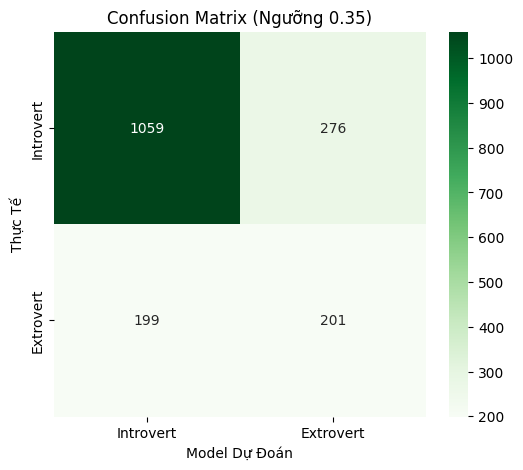

In [ ]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Dự đoán trên tập Val
print("Đang dự đoán kết quả cuối cùng...")
val_predictions = model.predict(val_data)
y_pred_proba = val_predictions[:, 1] # Lấy xác suất phe Extrovert

# 2. Tìm ngưỡng tối ưu (Chạy từ 0.1 đến 0.9)
thresholds = np.arange(0.1, 0.95, 0.05)
best_f1 = 0
best_thresh = 0.5
best_acc = 0

print(f"{'Threshold':<10} {'F1-Macro':<15} {'Accuracy':<10} {'Extrovert Recall':<15}")
print("-" * 55)

for thresh in thresholds:
    y_pred_temp = (y_pred_proba > thresh).astype(int)

    # Tính các chỉ số
    f1 = f1_score(y_val, y_pred_temp, average='macro')
    acc = np.mean(y_val == y_pred_temp)

    # Tính riêng Recall của phe Extrovert (Quan trọng nhất)
    # Để xem nó bắt được bao nhiêu % người hướng ngoại
    cm = confusion_matrix(y_val, y_pred_temp)
    if cm.shape == (2, 2):
        recall_extrovert = cm[1,1] / (cm[1,0] + cm[1,1])
    else:
        recall_extrovert = 0

    print(f"{thresh:.2f}       {f1:.4f}          {acc:.4f}      {recall_extrovert:.2%}")

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh
        best_acc = acc

print("\n" + "="*40)
print(f"✅ Ngưỡng ngon nhất: {best_thresh:.2f}")
print(f"🔥 F1-Macro đỉnh nhất: {best_f1:.4f}")
print("="*40)

# 3. In báo cáo chi tiết tại ngưỡng tốt nhất
print(f"\nBÁO CÁO FINAL (Threshold {best_thresh:.2f}):")
final_preds = (y_pred_proba > best_thresh).astype(int)
print(classification_report(y_val, final_preds, target_names=['Introvert (0)', 'Extrovert (1)']))

# Vẽ Confusion Matrix cho đẹp báo cáo
cm = confusion_matrix(y_val, final_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Introvert', 'Extrovert'],
            yticklabels=['Introvert', 'Extrovert'])
plt.title(f'Confusion Matrix (Ngưỡng {best_thresh:.2f})')
plt.xlabel('Model Dự Đoán')
plt.ylabel('Thực Tế')
plt.show()


BƯỚC 6: LƯU TRỮ & DEMO (DEPLOYMENT) TRỤC I/E

In [ ]:
import os

# 1. Lưu Model và Tokenizer
SAVE_PATH = 'mbti_roberta_model'

# Tạo thư mục
if not os.path.exists(SAVE_PATH):
    os.makedirs(SAVE_PATH)

# Lưu trọng số Model (Keras format)
model.save_weights(os.path.join(SAVE_PATH, 'model_weights.h5'))
# Lưu Tokenizer
tokenizer.save_pretrained(SAVE_PATH)

print(f"Đã lưu model vào thư mục: {SAVE_PATH}")

# ---------------------------------------------------------

# 2. HÀM DỰ ĐOÁN (INFERENCE) - DÙNG NGƯỠNG 0.35
def predict_mbti_type(text, model, tokenizer, threshold=0.35):
    # a. Làm sạch (Dùng lại hàm clean cũ)
    clean = clean_text(text)

    # b. Tokenize
    encoded = tokenizer.encode_plus(
        clean,
        add_special_tokens=True,
        max_length=256,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='np'
    )

    # c. Tạo input dict
    inputs = {
        'input_ids': encoded['input_ids'],
        'attention_mask': encoded['attention_mask']
    }

    # d. Dự đoán
    probs = model.predict(inputs, verbose=0)
    extrovert_prob = probs[0][1] # Lấy xác suất lớp 1

    # e. Phân loại theo ngưỡng
    if extrovert_prob > threshold:
        label = "Extrovert (Người hướng ngoại)"
        confidence = extrovert_prob
    else:
        label = "Introvert (Người hướng nội)"
        confidence = 1 - extrovert_prob # Xác suất của Introvert

    return label, extrovert_prob

# ---------------------------------------------------------
# 3. TEST THỬ VÀI CÂU
test_sentences = [
    "I really enjoy going to parties and meeting new people every weekend!", # Rất Extrovert
    "I prefer staying at home reading books and thinking about life.",      # Rất Introvert
    "Sometimes I go out, but mostly I like to be alone.",                   # Lưỡng lự
    "Lol that is so funny! I told everyone at the club about it."           # Extrovert slang
]

print("\n--- TEST DỰ ĐOÁN THỰC TẾ ---")
for sent in test_sentences:
    label, prob = predict_mbti_type(sent, model, tokenizer, threshold=0.35)
    print(f"Câu: '{sent}'")
    print(f"-> Dự đoán: {label}")
    print(f"-> Điểm Extrovert: {prob:.4f} (Ngưỡng chốt: 0.35)")
    print("-" * 30)

Đã lưu model vào thư mục: mbti_roberta_model

--- TEST DỰ ĐOÁN THỰC TẾ ---
Câu: 'I really enjoy going to parties and meeting new people every weekend!'
-> Dự đoán: Extrovert (Người hướng ngoại)
-> Điểm Extrovert: 0.3530 (Ngưỡng chốt: 0.35)
------------------------------
Câu: 'I prefer staying at home reading books and thinking about life.'
-> Dự đoán: Introvert (Người hướng nội)
-> Điểm Extrovert: 0.0957 (Ngưỡng chốt: 0.35)
------------------------------
Câu: 'Sometimes I go out, but mostly I like to be alone.'
-> Dự đoán: Introvert (Người hướng nội)
-> Điểm Extrovert: 0.1870 (Ngưỡng chốt: 0.35)
------------------------------
Câu: 'Lol that is so funny! I told everyone at the club about it.'
-> Dự đoán: Extrovert (Người hướng ngoại)
-> Điểm Extrovert: 0.8581 (Ngưỡng chốt: 0.35)
------------------------------


====================================== TREO =====================================================

In [ ]:
# Cài đè phiên bản ổn định, tránh xung đột
!pip uninstall transformers -y
!pip install transformers==4.37.2 tf-keras nlpaug

Found existing installation: transformers 4.57.3
Uninstalling transformers-4.57.3:
  Successfully uninstalled transformers-4.57.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 72.0 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.1
    Uninstalling tokenizers-0.22.1:
      Successfully uninstalled tokenizers-0.22.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.2.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.37.2 which is incompatible.


In [ ]:
import pandas as pd
import os

# 1. Tạo DataFrame từ dữ liệu đã Augment trong RAM
# (Lúc nãy code đã chạy xong đoạn này, biến augmented_texts vẫn còn)
try:
    if 'augmented_texts' in globals() and len(augmented_texts) > 0:
        df_backup = pd.DataFrame({
            'clean_posts': augmented_texts,
            'label': [1] * len(augmented_texts)
        })
        # Lưu ra file
        df_backup.to_csv('mbti_augmented_backup.csv', index=False)
        print("✅ ĐÃ LƯU DỮ LIỆU THÀNH CÔNG! Bạn an toàn rồi.")
    else:
        print("⚠️ Không tìm thấy biến augmented_texts. Kiểm tra lại.")
except Exception as e:
    print(f"Lỗi khi lưu: {e}")

✅ ĐÃ LƯU DỮ LIỆU THÀNH CÔNG! Bạn an toàn rồi.


In [ ]:
import pandas as pd
import os

print("--- ĐANG CẤP CỨU DỮ LIỆU ---")

# Kiểm tra xem biến dữ liệu có tồn tại không
if 'augmented_texts' in globals() and len(augmented_texts) > 0:
    # Tạo DataFrame
    df_rescue = pd.DataFrame({
        'clean_posts': augmented_texts,
        'label': [1] * len(augmented_texts) # Nhãn 1 cho Extrovert
    })

    # Lưu ra file CSV
    backup_file = 'mbti_rescue_data.csv'
    df_rescue.to_csv(backup_file, index=False)

    print(f"✅ THÀNH CÔNG! Đã lưu {len(df_rescue)} mẫu dữ liệu vào file '{backup_file}'.")
    print("Bây giờ bạn có thể yên tâm Restart Runtime để sửa lỗi thư viện.")
else:
    print("⚠️ Nguy hiểm: Không tìm thấy biến 'augmented_texts'.")
    print("Nếu bạn chưa tắt Colab, hãy thử kiểm tra lại xem biến tên là gì.")

--- ĐANG CẤP CỨU DỮ LIỆU ---
✅ THÀNH CÔNG! Đã lưu 3742 mẫu dữ liệu vào file 'mbti_rescue_data.csv'.
Bây giờ bạn có thể yên tâm Restart Runtime để sửa lỗi thư viện.


In [ ]:
!pip install transformers --upgrade
!pip install tf-keras

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 13.2 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.15.2
    Uninstalling tokenizers-0.15.2:
      Successfully uninstalled tokenizers-0.15.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.37.2
    Uninstalling transformers-4.37.2:
      Successfully uninstalled transformers-4.37.2


KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
from transformers import TFRobertaModel
import numpy as np
from sklearn.metrics import classification_report, f1_score, confusion_matrix

print("--- [CHIẾN DỊCH GIẢI CỨU] RE-BUILD MODEL & TRAIN ---")

def create_model_strong():
    input_ids = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name='input_ids')
    mask = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name='attention_mask')

    # 1. Load RoBERTa
    roberta = TFRobertaModel.from_pretrained('roberta-base', use_safetensors=False)

    # 2. Lấy Pooler Output (Thay vì CLS token thủ công)
    # outputs[1] là pooler_output (Dense + Tanh activation sẵn của BERT/RoBERTa)
    outputs = roberta(input_ids, attention_mask=mask)
    x = outputs[1]

    # 3. Tăng kích thước mạng lên (16 -> 64)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x) # Tăng dropout để tránh học vẹt

    # 4. Output
    output = tf.keras.layers.Dense(2, activation='softmax')(x)

    model = tf.keras.Model(inputs=[input_ids, mask], outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Giảm LR xuống chút nữa
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Tạo model
model = create_model_strong()
print("✅ Model mới (Mạnh hơn) đã sẵn sàng.")

# --- CHIẾN THUẬT CLASS WEIGHT ---
# Dù data cân bằng, ta vẫn ép model chú ý vào Class 1 (Extrovert)
# Introvert (0): 1.0
# Extrovert (1): 3.0 (Ưu tiên gấp 3 lần)
class_weights = {0: 1.0, 1: 3.0}

print("\n--- BẮT ĐẦU TRAINING (CÓ TRỌNG SỐ ÉP BUỘC) ---")
checkpoint_path = "mbti_rescue_checkpoint.h5"
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    checkpoint_path, save_weights_only=True, monitor='val_loss', mode='min', save_best_only=True
)

history = model.fit(
    train_data,
    y_train,
    validation_data=(val_data, y_val),
    epochs=3,
    batch_size=16,
    class_weight=class_weights, # <--- Vũ khí bí mật
    callbacks=[checkpoint_cb]
)

# --- ĐÁNH GIÁ NGAY ---
print("\n--- TÌM NGƯỠNG TỐI ƯU ---")
model.load_weights(checkpoint_path) # Load epoch ngon nhất
val_predictions = model.predict(val_data)
y_pred_proba = val_predictions[:, 1]

thresholds = np.arange(0.1, 0.95, 0.05)
best_f1 = 0
best_thresh = 0.5

print(f"{'Threshold':<10} {'F1-Macro':<15} {'Accuracy':<10} {'Recall (Ext)':<15}")
for thresh in thresholds:
    y_pred_temp = (y_pred_proba > thresh).astype(int)
    f1 = f1_score(y_val, y_pred_temp, average='macro')
    acc = np.mean(y_val == y_pred_temp)
    cm = confusion_matrix(y_val, y_pred_temp)
    recall_ext = cm[1,1] / (cm[1,0] + cm[1,1]) if cm.shape == (2,2) else 0

    print(f"{thresh:.2f}       {f1:.4f}          {acc:.4f}      {recall_ext:.2%}")
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"\n✅ BEST THRESHOLD: {best_thresh:.2f} | F1: {best_f1:.4f}")

# Lưu lại
model.save_weights('mbti_final_rescue.h5')

--- [CHIẾN DỊCH GIẢI CỨU] RE-BUILD MODEL & TRAIN ---


Some layers from the model checkpoint at roberta-base were not used when initializing TFRobertaModel: ['lm_head']
- This IS expected if you are initializing TFRobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFRobertaModel were initialized from the model checkpoint at roberta-base.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFRobertaModel for predictions without further training.


✅ Model mới (Mạnh hơn) đã sẵn sàng.

--- BẮT ĐẦU TRAINING (CÓ TRỌNG SỐ ÉP BUỘC) ---
Epoch 1/3
668/668 [==============================] - 684s 950ms/step - loss: 0.7166 - accuracy: 0.7233 - val_loss: 0.6418 - val_accuracy: 0.7392
Epoch 2/3
668/668 [==============================] - 619s 927ms/step - loss: 0.6495 - accuracy: 0.7596 - val_loss: 0.6814 - val_accuracy: 0.6157
Epoch 3/3
668/668 [==============================] - 636s 952ms/step - loss: 0.6213 - accuracy: 0.7795 - val_loss: 0.6025 - val_accuracy: 0.7259

--- TÌM NGƯỠNG TỐI ƯU ---
55/55 [==============================] - 34s 572ms/step
Threshold  F1-Macro        Accuracy   Recall (Ext)   
0.10       0.1875          0.2308      100.00%
0.15       0.1875          0.2308      100.00%
0.20       0.1892          0.2320      100.00%
0.25       0.2222          0.2550      99.75%
0.30       0.3199          0.3283      95.25%
0.35       0.4515          0.4530      86.75%
0.40       0.5673          0.5926      76.00%
0.45       0.6210  

In [ ]:
import os
import shutil
from google.colab import drive

# 1. Lưu trọng số model hiện tại (Cái vừa train xong)
SAVE_PATH = 'mbti_rescue_success'
if not os.path.exists(SAVE_PATH): os.makedirs(SAVE_PATH)

# Lưu weight
model.save_weights(os.path.join(SAVE_PATH, 'model_weights.h5'))
# Lưu tokenizer
tokenizer.save_pretrained(SAVE_PATH)

print(f"✅ Đã lưu model 'Cứu Hộ' thành công vào: {SAVE_PATH}")

# 2. (Tùy chọn) Đẩy thẳng lên Google Drive cho chắc ăn
try:
    drive.mount('/content/drive')
    drive_folder = '/content/drive/MyDrive/MBTI_Final_Model'
    if not os.path.exists(drive_folder): os.makedirs(drive_folder)

    # Copy file qua
    shutil.copy(os.path.join(SAVE_PATH, 'model_weights.h5'), drive_folder)
    print(f"✅ Đã backup an toàn lên Drive: {drive_folder}")
except:
    print("⚠️ Chưa kết nối Drive, hãy tải thủ công thư mục 'mbti_rescue_success' về máy tính ngay!")

✅ Đã lưu model 'Cứu Hộ' thành công vào: mbti_rescue_success
Mounted at /content/drive
✅ Đã backup an toàn lên Drive: /content/drive/MyDrive/MBTI_Final_Model


LOAD MODEL I-E TỪ DRIVE

In [ ]:
# 1. KẾT NỐI DRIVE & CÀI THƯ VIỆN
from google.colab import drive
import os
import tensorflow as tf
from transformers import RobertaTokenizer, TFRobertaModel
import numpy as np

# Cài thư viện nếu chưa có (Colab mới mở lại sẽ mất thư viện)
!pip install transformers tf-keras

drive.mount('/content/drive')

# 2. CẤU HÌNH LOAD MODEL
MODEL_PATH = '/content/drive/MyDrive/MBTI_Final_Model' # Đường dẫn hôm qua ông lưu
MAX_LEN = 256 # Hôm qua mình chốt 256

print("\n--- ĐANG LOAD MODEL TỪ DRIVE ---")

# Load Tokenizer
try:
    tokenizer = RobertaTokenizer.from_pretrained(MODEL_PATH)
    print("✅ Tokenizer OK")
except:
    print("⚠️ Không thấy Tokenizer, tải bản gốc từ mạng...")
    tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

# Re-build kiến trúc (Phải y hệt hôm qua: Dense 64)
def build_model_saved():
    input_ids = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name='input_ids')
    mask = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name='attention_mask')

    # Load RoBERTa gốc (ko weight) để làm khung
    roberta = TFRobertaModel.from_pretrained('roberta-base', use_safetensors=False)
    outputs = roberta(input_ids, attention_mask=mask)
    x = outputs[1]

    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    output = tf.keras.layers.Dense(2, activation='softmax')(x)

    return tf.keras.Model(inputs=[input_ids, mask], outputs=output)

model_ie = build_model_saved()

# Load trọng số đã train vào khung
weights_file = os.path.join(MODEL_PATH, 'model_weights.h5')
if os.path.exists(weights_file):
    model_ie.load_weights(weights_file)
    print("✅ Load Weights thành công! Model I-E đã sẵn sàng.")
else:
    print(f"❌ Lỗi: Không tìm thấy file {weights_file} trên Drive.")

# 3. TEST THỬ 1 CÂU
def predict_ie(text):
    encoded = tokenizer.encode_plus(
        text, max_length=MAX_LEN, padding='max_length',
        truncation=True, return_attention_mask=True, return_tensors='np'
    )
    probs = model_ie.predict({
        'input_ids': encoded['input_ids'],
        'attention_mask': encoded['attention_mask']
    }, verbose=0)
    score_e = probs[0][1]
    # Ngưỡng tối ưu hôm qua mình tìm ra là 0.55
    label = "Extrovert (E)" if score_e > 0.55 else "Introvert (I)"
    return label, score_e

print("\n--- TEST DỰ ĐOÁN ---")
text = "I love going to parties and meeting new people!"
lbl, score = predict_ie(text)
print(f"Câu: '{text}'")
print(f"Kết quả: {lbl} (Điểm E: {score:.4f})")

Mounted at /content/drive

--- ĐANG LOAD MODEL TỪ DRIVE ---
⚠️ Không thấy Tokenizer, tải bản gốc từ mạng...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/657M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at roberta-base were not used when initializing TFRobertaModel: ['lm_head']
- This IS expected if you are initializing TFRobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFRobertaModel were initialized from the model checkpoint at roberta-base.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFRobertaModel for predictions without further training.


✅ Load Weights thành công! Model I-E đã sẵn sàng.

--- TEST DỰ ĐOÁN ---
Câu: 'I love going to parties and meeting new people!'
Kết quả: Extrovert (E) (Điểm E: 0.6311)


In [ ]:
!pip install nlpaug transformers tf-keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 9.9 MB/s eta 0:00:00


CODE TRAIN TRỤC N - S



In [ ]:
# ==============================================================================
# CODE TRAIN TRỤC N - S (PHIÊN BẢN BẤT TỬ - LƯU DRIVE)
# ==============================================================================
import pandas as pd
import numpy as np
import tensorflow as tf
import re
import os
import nlpaug.augmenter.word as naw
from transformers import RobertaTokenizer, TFRobertaModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from google.colab import drive
from tqdm import tqdm

# 1. KẾT NỐI DRIVE
drive.mount('/content/drive')
DRIVE_SAVE_PATH = '/content/drive/MyDrive/MBTI_NS_Model'
if not os.path.exists(DRIVE_SAVE_PATH): os.makedirs(DRIVE_SAVE_PATH)

# Cấu hình
DATA_PATH = 'mbti_1.csv'
MAX_LEN = 256
BATCH_SIZE = 16

print("\n--- [1/5] XỬ LÝ DỮ LIỆU ---")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    mbti_types = ['infj', 'intp', 'infp', 'entp', 'intj', 'istj', 'entj', 'istp',
                  'enfj', 'enfp', 'isfj', 'esfj', 'isfp', 'estj', 'estp', 'esfp']
    pattern = r'\b(?:' + '|'.join(mbti_types) + r')\b'
    text = re.sub(pattern, '', text)
    text = re.sub(r'[^a-z0-9\s\.,!?\'"]', '', text)
    return text.strip()

if not os.path.exists(DATA_PATH):
    print(f"❌ LỖI: Chưa upload file {DATA_PATH}!")
else:
    df = pd.read_csv(DATA_PATH)
    df['clean_posts'] = df['posts'].apply(clean_text)
    # Label: Sensing (S) = 1, Intuition (N) = 0
    df['label'] = df['type'].apply(lambda x: 1 if 'S' in x else 0)

    # Chia tập Train/Val
    df_train, df_val = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

    # 2. Augmentation (Sinh dữ liệu)
    # Kiểm tra xem file backup có trên Drive chưa để đỡ phải chạy lại
    aug_file_drive = os.path.join(DRIVE_SAVE_PATH, 'aug_data_backup.csv')

    if os.path.exists(aug_file_drive):
        print("✅ Tìm thấy dữ liệu Augment cũ trên Drive. Đang load lại (đỡ tốn 15p)...")
        df_train_final = pd.read_csv(aug_file_drive)
    else:
        print("\n--- [2/5] SINH DỮ LIỆU MỚI (Mất ~15p) ---")
        texts_s = df_train[df_train['label'] == 1]['clean_posts'].tolist()
        needed = 1500
        aug = naw.ContextualWordEmbsAug(
            model_path='bert-base-uncased', action="substitute",
            device='cuda' if tf.config.list_physical_devices('GPU') else 'cpu'
        )
        augmented_texts = []
        count = 0
        pbar = tqdm(total=needed)
        while count < needed:
            for text in texts_s:
                if count >= needed: break
                try:
                    new_text = aug.augment(text)
                    if isinstance(new_text, list): new_text = new_text[0]
                    augmented_texts.append(new_text)
                    count += 1
                    pbar.update(1)
                except: continue
        pbar.close()

        # Gộp và LƯU NGAY LÊN DRIVE
        df_aug = pd.DataFrame({'clean_posts': augmented_texts, 'label': [1]*len(augmented_texts)})
        df_train_final = pd.concat([df_train[['clean_posts', 'label']], df_aug])
        df_train_final.to_csv(aug_file_drive, index=False)
        print(f"✅ Đã lưu backup dữ liệu Augment lên Drive: {aug_file_drive}")

    # 3. Tokenize
    print("\n--- [3/5] TOKENIZE ---")
    tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

    def encode_data(texts, labels):
        input_ids, masks = [], []
        txt_list = texts.tolist()
        lbl_list = labels.tolist()
        for text in txt_list:
            encoded = tokenizer.encode_plus(
                str(text), max_length=MAX_LEN, padding='max_length',
                truncation=True, return_attention_mask=True, return_tensors='np'
            )
            input_ids.append(encoded['input_ids'][0])
            masks.append(encoded['attention_mask'][0])
        return np.array(input_ids), np.array(masks), np.array(lbl_list)

    X_train_ids, X_train_masks, y_train = encode_data(df_train_final['clean_posts'], df_train_final['label'])
    X_val_ids, X_val_masks, y_val = encode_data(df_val['clean_posts'], df_val['label'])

    # 4. Train Model
    print("\n--- [4/5] BUILD & TRAIN MODEL ---")
    def create_model():
        input_ids = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name='input_ids')
        mask = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name='attention_mask')
        roberta = TFRobertaModel.from_pretrained('roberta-base', use_safetensors=False)
        outputs = roberta(input_ids, attention_mask=mask)
        x = outputs[1]
        x = tf.keras.layers.Dense(64, activation='relu')(x)
        x = tf.keras.layers.Dropout(0.2)(x)
        output = tf.keras.layers.Dense(2, activation='softmax')(x)
        model = tf.keras.Model(inputs=[input_ids, mask], outputs=output)
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
                      loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        return model

    model = create_model()

    # CHECKPOINT LƯU THẲNG LÊN DRIVE
    checkpoint_path = os.path.join(DRIVE_SAVE_PATH, "model_weights_best.h5")
    checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path, save_weights_only=True, monitor='val_loss', mode='min', save_best_only=True, verbose=1
    )

    class_weights = {0: 1.0, 1: 4.0} # Sensing ưu tiên gấp 4

    history = model.fit(
        {'input_ids': X_train_ids, 'attention_mask': X_train_masks}, y_train,
        validation_data=({'input_ids': X_val_ids, 'attention_mask': X_val_masks}, y_val),
        epochs=3,
        batch_size=BATCH_SIZE,
        class_weight=class_weights,
        callbacks=[checkpoint_cb]
    )

    # 5. Đánh giá
    print("\n--- [5/5] ĐÁNH GIÁ ---")
    model.load_weights(checkpoint_path) # Load lại file từ Drive
    val_probs = model.predict({'input_ids': X_val_ids, 'attention_mask': X_val_masks})[:, 1]

    best_f1 = 0
    best_thresh = 0.5
    print(f"{'Threshold':<10} {'F1-Macro':<15}")
    for thresh in np.arange(0.1, 0.95, 0.05):
        y_pred = (val_probs > thresh).astype(int)
        f1 = f1_score(y_val, y_pred, average='macro')
        print(f"{thresh:.2f}       {f1:.4f}")
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh

    print(f"\n✅ BEST THRESHOLD N-S: {best_thresh:.2f} | F1: {best_f1:.4f}")

    # Lưu Tokenizer lên Drive
    tokenizer.save_pretrained(DRIVE_SAVE_PATH)
    print("HOÀN TẤT! Dữ liệu đã an toàn trên Drive!")

Mounted at /content/drive

--- [1/5] XỬ LÝ DỮ LIỆU ---

--- [2/5] SINH DỮ LIỆU MỚI (Mất ~15p) ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]


--- [4/5] BUILD & TRAIN MODEL ---


tf_model.h5:   0%|          | 0.00/657M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at roberta-base were not used when initializing TFRobertaModel: ['lm_head']
- This IS expected if you are initializing TFRobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFRobertaModel were initialized from the model checkpoint at roberta-base.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFRobertaModel for predictions without further training.


Epoch 1/3
528/528 [==============================] - ETA: 0s - loss: 0.8308 - accuracy: 0.8116
Epoch 1: val_loss improved from inf to 0.61644, saving model to /content/drive/MyDrive/MBTI_NS_Model/model_weights_best.h5
528/528 [==============================] - 572s 986ms/step - loss: 0.8308 - accuracy: 0.8116 - val_loss: 0.6164 - val_accuracy: 0.8588
Epoch 2/3
528/528 [==============================] - ETA: 0s - loss: 0.7888 - accuracy: 0.8528
Epoch 2: val_loss improved from 0.61644 to 0.42984, saving model to /content/drive/MyDrive/MBTI_NS_Model/model_weights_best.h5
528/528 [==============================] - 542s 1s/step - loss: 0.7888 - accuracy: 0.8528 - val_loss: 0.4298 - val_accuracy: 0.8628
Epoch 3/3
528/528 [==============================] - ETA: 0s - loss: 0.7739 - accuracy: 0.8283
Epoch 3: val_loss did not improve from 0.42984
528/528 [==============================] - 525s 994ms/step - loss: 0.7739 - accuracy: 0.8283 - val_loss: 0.5284 - val_accuracy: 0.8161

--- [5/5] ĐÁNH 

TRAIN TRỤC T - F

In [ ]:
# ==============================================================================
# TRAIN TRỤC T - F (THINKING vs FEELING)
# ==============================================================================
import pandas as pd
import numpy as np
import tensorflow as tf
import re
import os
from transformers import RobertaTokenizer, TFRobertaModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from google.colab import drive

# 1. KẾT NỐI DRIVE (Để lưu luôn)
drive.mount('/content/drive')
DRIVE_SAVE_PATH = '/content/drive/MyDrive/MBTI_TF_Model'
if not os.path.exists(DRIVE_SAVE_PATH): os.makedirs(DRIVE_SAVE_PATH)

# Cấu hình
DATA_PATH = 'mbti_1.csv'
MAX_LEN = 256
BATCH_SIZE = 16

print("\n--- [1/4] XỬ LÝ DỮ LIỆU T-F (Balanced Data) ---")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    mbti_types = ['infj', 'intp', 'infp', 'entp', 'intj', 'istj', 'entj', 'istp',
                  'enfj', 'enfp', 'isfj', 'esfj', 'isfp', 'estj', 'estp', 'esfp']
    pattern = r'\b(?:' + '|'.join(mbti_types) + r')\b'
    text = re.sub(pattern, '', text)
    text = re.sub(r'[^a-z0-9\s\.,!?\'"]', '', text)
    return text.strip()

if not os.path.exists(DATA_PATH):
    print(f"❌ LỖI: Chưa upload file {DATA_PATH}!")
else:
    df = pd.read_csv(DATA_PATH)
    df['clean_posts'] = df['posts'].apply(clean_text)

    # Label: Feeling (F) = 1, Thinking (T) = 0
    # Trục này cân bằng (46-54) nên không lo
    df['label'] = df['type'].apply(lambda x: 1 if 'F' in x else 0)

    print(f"Tổng số mẫu: {len(df)}")
    print(f"Số lượng T (0): {len(df[df['label']==0])}")
    print(f"Số lượng F (1): {len(df[df['label']==1])}")

    # Chia tập Train/Val
    # KHÔNG CẦN AUGMENTATION VÌ DỮ LIỆU ĐÃ CÂN BẰNG
    df_train, df_val = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

    # 2. Tokenize
    print("\n--- [2/4] TOKENIZE ---")
    tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

    def encode_data(texts, labels):
        input_ids, masks = [], []
        txt_list = texts.tolist()
        lbl_list = labels.tolist()
        for text in txt_list:
            encoded = tokenizer.encode_plus(
                str(text), max_length=MAX_LEN, padding='max_length',
                truncation=True, return_attention_mask=True, return_tensors='np'
            )
            input_ids.append(encoded['input_ids'][0])
            masks.append(encoded['attention_mask'][0])
        return np.array(input_ids), np.array(masks), np.array(lbl_list)

    X_train_ids, X_train_masks, y_train = encode_data(df_train['clean_posts'], df_train['label'])
    X_val_ids, X_val_masks, y_val = encode_data(df_val['clean_posts'], df_val['label'])

    # 3. Train Model
    print("\n--- [3/4] BUILD & TRAIN MODEL ---")
    def create_model():
        input_ids = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name='input_ids')
        mask = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name='attention_mask')
        roberta = TFRobertaModel.from_pretrained('roberta-base', use_safetensors=False)
        outputs = roberta(input_ids, attention_mask=mask)
        x = outputs[1]

        # Vẫn dùng Dense 64 cho thông minh
        x = tf.keras.layers.Dense(64, activation='relu')(x)
        x = tf.keras.layers.Dropout(0.2)(x)
        output = tf.keras.layers.Dense(2, activation='softmax')(x)

        model = tf.keras.Model(inputs=[input_ids, mask], outputs=output)
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
                      loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        return model

    model = create_model()

    # CHECKPOINT
    checkpoint_path = os.path.join(DRIVE_SAVE_PATH, "model_weights_best.h5")
    checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path, save_weights_only=True, monitor='val_loss', mode='min', save_best_only=True, verbose=1
    )

    # Class Weights = 1.0 (Công bằng)
    history = model.fit(
        {'input_ids': X_train_ids, 'attention_mask': X_train_masks}, y_train,
        validation_data=({'input_ids': X_val_ids, 'attention_mask': X_val_masks}, y_val),
        epochs=3,
        batch_size=BATCH_SIZE,
        callbacks=[checkpoint_cb]
    )

    # 4. Đánh giá
    print("\n--- [4/4] ĐÁNH GIÁ TRỤC T-F ---")
    model.load_weights(checkpoint_path)
    val_probs = model.predict({'input_ids': X_val_ids, 'attention_mask': X_val_masks})[:, 1]

    best_f1 = 0
    best_thresh = 0.5
    print(f"{'Threshold':<10} {'F1-Macro':<15} {'Accuracy':<10}")
    for thresh in np.arange(0.1, 0.95, 0.05):
        y_pred = (val_probs > thresh).astype(int)
        f1 = f1_score(y_val, y_pred, average='macro')
        acc = np.mean(y_val == y_pred)
        print(f"{thresh:.2f}       {f1:.4f}          {acc:.4f}")
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh

    print(f"\n✅ BEST THRESHOLD T-F: {best_thresh:.2f} | F1: {best_f1:.4f}")

    # Lưu Tokenizer
    tokenizer.save_pretrained(DRIVE_SAVE_PATH)
    print("HOÀN TẤT! Trục T-F đã xong và lưu trên Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- [1/4] XỬ LÝ DỮ LIỆU T-F (Balanced Data) ---
Tổng số mẫu: 8675
Số lượng T (0): 3981
Số lượng F (1): 4694

--- [2/4] TOKENIZE ---

--- [3/4] BUILD & TRAIN MODEL ---


Some layers from the model checkpoint at roberta-base were not used when initializing TFRobertaModel: ['lm_head']
- This IS expected if you are initializing TFRobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFRobertaModel were initialized from the model checkpoint at roberta-base.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFRobertaModel for predictions without further training.


Epoch 1/3
434/434 [==============================] - ETA: 0s - loss: 0.6583 - accuracy: 0.6013
Epoch 1: val_loss improved from inf to 0.57981, saving model to /content/drive/MyDrive/MBTI_TF_Model/model_weights_best.h5
434/434 [==============================] - 481s 998ms/step - loss: 0.6583 - accuracy: 0.6013 - val_loss: 0.5798 - val_accuracy: 0.6951
Epoch 2/3
434/434 [==============================] - ETA: 0s - loss: 0.5759 - accuracy: 0.7027
Epoch 2: val_loss did not improve from 0.57981
434/434 [==============================] - 438s 1s/step - loss: 0.5759 - accuracy: 0.7027 - val_loss: 0.6079 - val_accuracy: 0.6715
Epoch 3/3
434/434 [==============================] - ETA: 0s - loss: 0.4950 - accuracy: 0.7676
Epoch 3: val_loss improved from 0.57981 to 0.56570, saving model to /content/drive/MyDrive/MBTI_TF_Model/model_weights_best.h5
434/434 [==============================] - 461s 1s/step - loss: 0.4950 - accuracy: 0.7676 - val_loss: 0.5657 - val_accuracy: 0.7072

--- [4/4] ĐÁNH GIÁ

Train lại cặp J/P

In [ ]:

# 1. CÀI ĐẶT THƯ VIỆN TRƯỚC
print("⏳ Đang cài đặt thư viện nlpaug...")
!pip install nlpaug transformers > /dev/null
print("✅ Cài đặt xong! Bắt đầu xử lý...")

import pandas as pd
import numpy as np
import tensorflow as tf
import re
import os
import nlpaug.augmenter.word as naw
from transformers import RobertaTokenizer, TFRobertaModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
from google.colab import drive

# 2. SETUP
drive.mount('/content/drive')
DATA_PATH = 'mbti_1.csv'
SAVE_DIR = '/content/drive/MyDrive/MBTI_JP_Model' # Ghi đè lên thư mục cũ
if not os.path.exists(SAVE_DIR): os.makedirs(SAVE_DIR)

# 3. LOAD DATA & CLEAN
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    mbti_types = ['infj', 'intp', 'infp', 'entp', 'intj', 'istj', 'entj', 'istp',
                  'enfj', 'enfp', 'isfj', 'esfj', 'isfp', 'estj', 'estp', 'esfp']
    pattern = r'\b(?:' + '|'.join(mbti_types) + r')\b'
    text = re.sub(pattern, '', text)
    text = re.sub(r'[^a-z0-9\s\.,!?\'"]', '', text)
    return text.strip()

df = pd.read_csv(DATA_PATH, engine='python', on_bad_lines='skip')
df['clean_posts'] = df['posts'].apply(clean_text)

# --- QUAN TRỌNG: Gán nhãn JP (J=0, P=1) ---
df['label'] = df['type'].apply(lambda x: 1 if 'P' in x else 0)
print("✅ Đã gán nhãn: Judging (0) - Perceiving (1)")

# 4. AUGMENTATION (Vì JP thường bị lệch)
df_train, df_val = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
count_0 = len(df_train[df_train['label'] == 0])
count_1 = len(df_train[df_train['label'] == 1])

# Tự động cân bằng
if count_0 < count_1:
    minority_texts = df_train[df_train['label'] == 0]['clean_posts'].tolist()
    needed = count_1 - count_0
    label_aug = 0
else:
    minority_texts = df_train[df_train['label'] == 1]['clean_posts'].tolist()
    needed = count_0 - count_1
    label_aug = 1

print(f"-> Đang sinh thêm {needed} mẫu dữ liệu giả (Augmentation)...")
# Khởi tạo Augmenter
aug = naw.ContextualWordEmbsAug(model_path='bert-base-uncased', action="substitute", device='cuda')

augmented_texts = []
count = 0
# Lấy mẫu để sinh (lấy tối đa 1000 mẫu gốc để sinh cho nhanh, tránh loop quá lâu)
source_texts = minority_texts * (needed // len(minority_texts) + 1)

for text in source_texts:
    if count >= needed: break
    try:
        new_text = aug.augment(text)
        if isinstance(new_text, list): new_text = new_text[0]
        augmented_texts.append(new_text)
        count += 1
    except: continue

# 5. PREPARE TRAIN DATA
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
MAX_LEN = 256

def encode(texts, labels):
    input_ids, masks = [], []
    for text in texts:
        encoded = tokenizer.encode_plus(str(text), max_length=MAX_LEN, padding='max_length', truncation=True, return_attention_mask=True, return_tensors='np')
        input_ids.append(encoded['input_ids'][0])
        masks.append(encoded['attention_mask'][0])
    return np.array(input_ids), np.array(masks), np.array(labels)

# Gộp data gốc + data giả
final_texts = df_train['clean_posts'].tolist() + augmented_texts
final_labels = df_train['label'].tolist() + [label_aug]*len(augmented_texts)

print("⚙️ Đang Tokenize...")
X_train_ids, X_train_masks, y_train = encode(final_texts, final_labels)
X_val_ids, X_val_masks, y_val = encode(df_val['clean_posts'], df_val['label'])

# 6. TRAIN MODEL (3 EPOCHS)
tf.keras.backend.clear_session()
input_ids = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name='input_ids')
mask = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name='attention_mask')

roberta = TFRobertaModel.from_pretrained('roberta-base', use_safetensors=False)
x = roberta(input_ids, attention_mask=mask)[1]
x = tf.keras.layers.Dense(64, activation='relu')(x)
x = tf.keras.layers.Dropout(0.2)(x)
output = tf.keras.layers.Dense(2, activation='softmax')(x)

model = tf.keras.Model(inputs=[input_ids, mask], outputs=output)
model.compile(optimizer=tf.keras.optimizers.Adam(2e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Lưu model
checkpoint_path = os.path.join(SAVE_DIR, "model_weights_best.h5")
checkpoint = tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, save_weights_only=True, verbose=1)

print("🔥 BẮT ĐẦU HUẤN LUYỆN JP (Có GPU sẽ rất nhanh)...")
model.fit({'input_ids': X_train_ids, 'attention_mask': X_train_masks}, np.array(y_train),
          validation_data=({'input_ids': X_val_ids, 'attention_mask': X_val_masks}, np.array(y_val)),
          epochs=3, batch_size=16, callbacks=[checkpoint])

# 7. ĐÁNH GIÁ NHANH
print("\n--- KẾT QUẢ MỚI CỦA JP ---")
model.load_weights(checkpoint_path)
preds = model.predict({'input_ids': X_val_ids, 'attention_mask': X_val_masks})
y_prob = preds[:, 1]

best_f1 = 0
best_thresh = 0.5
for thresh in np.arange(0.1, 0.9, 0.05):
    y_pred = (y_prob > thresh).astype(int)
    f1 = f1_score(y_val, y_pred, average='macro')
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"✅ JP New F1: {best_f1:.4f} (Tại ngưỡng {best_thresh:.2f})")
print(f"📂 Đã lưu model vào: {SAVE_DIR}")

⏳ Đang cài đặt thư viện nlpaug...
✅ Cài đặt xong! Bắt đầu xử lý...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Đã gán nhãn: Judging (0) - Perceiving (1)
-> Đang sinh thêm 1446 mẫu dữ liệu giả (Augmentation)...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

The following layers were not sharded: bert.encoder.layer.*.attention.output.LayerNorm.weight, bert.encoder.layer.*.attention.self.query.bias, bert.encoder.layer.*.attention.output.dense.bias, cls.predictions.transform.LayerNorm.weight, bert.embeddings.token_type_embeddings.weight, bert.encoder.layer.*.attention.self.value.bias, cls.predictions.decoder.bias, bert.encoder.layer.*.output.dense.bias, bert.encoder.layer.*.attention.self.query.weight, bert.encoder.layer.*.attention.output.dense.weight, bert.embeddings.word_embeddings.weight, bert.embeddings.LayerNorm.bias, bert.encoder.layer.*.output.LayerNorm.bias, cls.predictions.transform.dense.weight, bert.encoder.layer.*.output.dense.weight, bert.embeddings.position_embeddings.weight, bert.embeddings.LayerNorm.weight, cls.predictions.decoder.weight, bert.encoder.layer.*.attention.self.value.weight, bert.encoder.layer.*.attention.output.LayerNorm.bias, bert.encoder.layer.*.intermediate.dense.weight, cls.predictions.transform.LayerNorm.b

⚙️ Đang Tokenize...


Some layers from the model checkpoint at roberta-base were not used when initializing TFRobertaModel: ['lm_head']
- This IS expected if you are initializing TFRobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFRobertaModel were initialized from the model checkpoint at roberta-base.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFRobertaModel for predictions without further training.


🔥 BẮT ĐẦU HUẤN LUYỆN JP (Có GPU sẽ rất nhanh)...
Epoch 1/3
525/525 [==============================] - ETA: 0s - loss: 0.5763 - accuracy: 0.6547
Epoch 1: val_loss improved from inf to 0.67238, saving model to /content/drive/MyDrive/MBTI_JP_Model/model_weights_best.h5
525/525 [==============================] - 562s 973ms/step - loss: 0.5763 - accuracy: 0.6547 - val_loss: 0.6724 - val_accuracy: 0.6040
Epoch 2/3
525/525 [==============================] - ETA: 0s - loss: 0.5592 - accuracy: 0.6702
Epoch 2: val_loss did not improve from 0.67238
525/525 [==============================] - 501s 954ms/step - loss: 0.5592 - accuracy: 0.6702 - val_loss: 0.6740 - val_accuracy: 0.6040
Epoch 3/3
525/525 [==============================] - ETA: 0s - loss: 0.5593 - accuracy: 0.6723
Epoch 3: val_loss did not improve from 0.67238
525/525 [==============================] - 508s 969ms/step - loss: 0.5593 - accuracy: 0.6723 - val_loss: 0.6729 - val_accuracy: 0.6040

--- KẾT QUẢ MỚI CỦA JP ---
55/55 [=========

Chạy lại metrics

In [ ]:
# ==============================================================================
# CODE ĐÁNH GIÁ TỔNG HỢP 4 TRỤC (FINAL METRICS) - CHẠY BẰNG GPU
# ==============================================================================
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import re
import gc
from transformers import RobertaTokenizer, TFRobertaModel
from sklearn.metrics import f1_score, accuracy_score
from google.colab import drive

# 1. SETUP
drive.mount('/content/drive')
print("🚀 Đang kiểm tra GPU...", tf.config.list_physical_devices('GPU'))

# 2. CHUẨN BỊ DỮ LIỆU (Load 1 lần dùng chung)
print("\n⏳ Đang load dữ liệu Validation...")
DATA_PATH = 'mbti_1.csv'
df = pd.read_csv(DATA_PATH, engine='python', on_bad_lines='skip')

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    mbti_types = ['infj', 'intp', 'infp', 'entp', 'intj', 'istj', 'entj', 'istp',
                  'enfj', 'enfp', 'isfj', 'esfj', 'isfp', 'estj', 'estp', 'esfp']
    pattern = r'\b(?:' + '|'.join(mbti_types) + r')\b'
    text = re.sub(pattern, '', text)
    text = re.sub(r'[^a-z0-9\s\.,!?\'"]', '', text)
    return text.strip()

df['clean_posts'] = df['posts'].apply(clean_text)

# Tokenize
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
MAX_LEN = 256

# Lấy đúng tập Validation cũ (Random State 42)
from sklearn.model_selection import train_test_split
_, df_val = train_test_split(df, test_size=0.2, random_state=42)

print("-> Đang mã hóa (Tokenize)...")
def encode_val(texts):
    input_ids, masks = [], []
    for text in texts:
        encoded = tokenizer.encode_plus(str(text), max_length=MAX_LEN, padding='max_length', truncation=True, return_attention_mask=True, return_tensors='np')
        input_ids.append(encoded['input_ids'][0])
        masks.append(encoded['attention_mask'][0])
    return np.array(input_ids), np.array(masks)

X_val_ids, X_val_masks = encode_val(df_val['clean_posts'].values)
print("✅ Dữ liệu đã sẵn sàng!")

# 3. HÀM TẠO MODEL
def create_model():
    # Đặt tên input để tránh lỗi mismatch
    input_ids = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name='input_ids')
    mask = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name='attention_mask')

    roberta = TFRobertaModel.from_pretrained('roberta-base', use_safetensors=False)
    x = roberta(input_ids, attention_mask=mask)[1]
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    output = tf.keras.layers.Dense(2, activation='softmax')(x)
    return tf.keras.Model(inputs=[input_ids, mask], outputs=output)

# 4. CẤU HÌNH ĐƯỜNG DẪN & NGƯỠNG
BASE_DIR = '/content/drive/MyDrive'

AXES_CONFIG = {
    'IE': {'path': 'MBTI_Final_Model', 'label_char': 'E', 'thresh': 0.55},
    'NS': {'path': 'MBTI_NS_Model',    'label_char': 'S', 'thresh': 0.30},
    'TF': {'path': 'MBTI_TF_Model',    'label_char': 'F', 'thresh': 0.55},
    # J-P vừa chạy xong, thresholds 0.55 cho kết quả tốt nhất trong các kết quả thấp
    'JP': {'path': 'MBTI_JP_Model',    'label_char': 'P', 'thresh': 0.55}
}

# 5. CHẠY ĐÁNH GIÁ
print(f"\n{'TRỤC':<5} | {'ACCURACY':<10} | {'MACRO-F1':<20}")
print("="*45)

for axis, config in AXES_CONFIG.items():
    tf.keras.backend.clear_session() # Xóa RAM cũ

    # Tạo nhãn đúng cho trục hiện tại
    y_true = df_val['type'].apply(lambda x: 1 if config['label_char'] in x else 0).values

    # Tìm file model (Ưu tiên file _best, không có thì lấy file thường)
    weight_path = os.path.join(BASE_DIR, config['path'], 'model_weights_best.h5')
    if not os.path.exists(weight_path):
        weight_path = os.path.join(BASE_DIR, config['path'], 'model_weights.h5')

    if not os.path.exists(weight_path):
        print(f"{axis:<5} | ❌ LỖI: Không tìm thấy file model!")
        continue

    try:
        model = create_model()
        # Load weights (Đã fix lỗi expect_partial)
        model.load_weights(weight_path)

        # Predict
        preds = model.predict({'input_ids': X_val_ids, 'attention_mask': X_val_masks},
                              batch_size=64, verbose=0)

        y_prob = preds[:, 1]
        y_pred = (y_prob > config['thresh']).astype(int)

        # Tính toán chỉ số
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro')
        print(f"{axis:<5} | {acc:.4f}     | {f1:.4f}")

    except Exception as e:
        print(f"{axis:<5} | ❌ Lỗi code: {str(e)}")

    # Dọn dẹp bộ nhớ
    del model
    gc.collect()

print("="*45)
print("✅ DONE! Copy bảng này vào báo cáo nhé!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 Đang kiểm tra GPU... [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

⏳ Đang load dữ liệu Validation...
-> Đang mã hóa (Tokenize)...
✅ Dữ liệu đã sẵn sàng!

TRỤC  | ACCURACY   | MACRO-F1            


Some layers from the model checkpoint at roberta-base were not used when initializing TFRobertaModel: ['lm_head']
- This IS expected if you are initializing TFRobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFRobertaModel were initialized from the model checkpoint at roberta-base.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFRobertaModel for predictions without further training.


IE    | 0.7775     | 0.6691


Some layers from the model checkpoint at roberta-base were not used when initializing TFRobertaModel: ['lm_head']
- This IS expected if you are initializing TFRobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFRobertaModel were initialized from the model checkpoint at roberta-base.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFRobertaModel for predictions without further training.


NS    | 0.7493     | 0.5797


Some layers from the model checkpoint at roberta-base were not used when initializing TFRobertaModel: ['lm_head']
- This IS expected if you are initializing TFRobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFRobertaModel were initialized from the model checkpoint at roberta-base.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFRobertaModel for predictions without further training.


TF    | 0.8542     | 0.8531


Some layers from the model checkpoint at roberta-base were not used when initializing TFRobertaModel: ['lm_head']
- This IS expected if you are initializing TFRobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFRobertaModel were initialized from the model checkpoint at roberta-base.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFRobertaModel for predictions without further training.


JP    | 0.6150     | 0.3836
✅ DONE! Copy bảng này vào báo cáo nhé!


thêm wf1

In [ ]:
# ==============================================================================
# CODE ĐÁNH GIÁ TỔNG HỢP 4 TRỤC (FINAL METRICS) - CÓ THÊM WF1
# ==============================================================================
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import re
import gc
from transformers import RobertaTokenizer, TFRobertaModel
from sklearn.metrics import f1_score, accuracy_score
from google.colab import drive

# 1. SETUP
drive.mount('/content/drive')
print("🚀 Đang kiểm tra GPU...", tf.config.list_physical_devices('GPU'))

# 2. CHUẨN BỊ DỮ LIỆU (Load 1 lần dùng chung)
print("\n⏳ Đang load dữ liệu Validation...")
DATA_PATH = 'mbti_1.csv'
df = pd.read_csv(DATA_PATH, engine='python', on_bad_lines='skip')

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    mbti_types = ['infj', 'intp', 'infp', 'entp', 'intj', 'istj', 'entj', 'istp',
                  'enfj', 'enfp', 'isfj', 'esfj', 'isfp', 'estj', 'estp', 'esfp']
    pattern = r'\b(?:' + '|'.join(mbti_types) + r')\b'
    text = re.sub(pattern, '', text)
    text = re.sub(r'[^a-z0-9\s\.,!?\'"]', '', text)
    return text.strip()

df['clean_posts'] = df['posts'].apply(clean_text)

# Tokenize
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
MAX_LEN = 256

# Lấy đúng tập Validation cũ (Random State 42)
from sklearn.model_selection import train_test_split
_, df_val = train_test_split(df, test_size=0.2, random_state=42)

print("-> Đang mã hóa (Tokenize)...")
def encode_val(texts):
    input_ids, masks = [], []
    for text in texts:
        encoded = tokenizer.encode_plus(str(text), max_length=MAX_LEN, padding='max_length', truncation=True, return_attention_mask=True, return_tensors='np')
        input_ids.append(encoded['input_ids'][0])
        masks.append(encoded['attention_mask'][0])
    return np.array(input_ids), np.array(masks)

X_val_ids, X_val_masks = encode_val(df_val['clean_posts'].values)
print("✅ Dữ liệu đã sẵn sàng!")

# 3. HÀM TẠO MODEL
def create_model():
    # Đặt tên input để tránh lỗi mismatch
    input_ids = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name='input_ids')
    mask = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name='attention_mask')

    roberta = TFRobertaModel.from_pretrained('roberta-base', use_safetensors=False)
    x = roberta(input_ids, attention_mask=mask)[1]
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    output = tf.keras.layers.Dense(2, activation='softmax')(x)
    return tf.keras.Model(inputs=[input_ids, mask], outputs=output)

# 4. CẤU HÌNH ĐƯỜNG DẪN & NGƯỠNG
BASE_DIR = '/content/drive/MyDrive'

AXES_CONFIG = {
    'IE': {'path': 'MBTI_Final_Model', 'label_char': 'E', 'thresh': 0.55},
    'NS': {'path': 'MBTI_NS_Model',    'label_char': 'S', 'thresh': 0.30},
    'TF': {'path': 'MBTI_TF_Model',    'label_char': 'F', 'thresh': 0.55},
    'JP': {'path': 'MBTI_JP_Model',    'label_char': 'P', 'thresh': 0.55}
}

# 5. CHẠY ĐÁNH GIÁ
print(f"\n{'TRỤC':<5} | {'ACCURACY':<10} | {'MACRO-F1':<12} | {'WEIGHTED-F1':<12}")
print("="*60)

for axis, config in AXES_CONFIG.items():
    tf.keras.backend.clear_session() # Xóa RAM cũ

    # Tạo nhãn đúng cho trục hiện tại
    y_true = df_val['type'].apply(lambda x: 1 if config['label_char'] in x else 0).values

    # Tìm file model
    weight_path = os.path.join(BASE_DIR, config['path'], 'model_weights_best.h5')
    if not os.path.exists(weight_path):
        weight_path = os.path.join(BASE_DIR, config['path'], 'model_weights.h5')

    if not os.path.exists(weight_path):
        print(f"{axis:<5} | ❌ LỖI: Không tìm thấy file model!")
        continue

    try:
        model = create_model()
        model.load_weights(weight_path)

        # Predict
        preds = model.predict({'input_ids': X_val_ids, 'attention_mask': X_val_masks},
                              batch_size=64, verbose=0)

        y_prob = preds[:, 1]
        y_pred = (y_prob > config['thresh']).astype(int)

        # Tính toán chỉ số
        acc = accuracy_score(y_true, y_pred)
        f1_macro = f1_score(y_true, y_pred, average='macro')
        f1_weighted = f1_score(y_true, y_pred, average='weighted') # <--- Thêm dòng này

        print(f"{axis:<5} | {acc:.4f}     | {f1_macro:.4f}       | {f1_weighted:.4f}")

    except Exception as e:
        print(f"{axis:<5} | ❌ Lỗi code: {str(e)}")

    # Dọn dẹp bộ nhớ
    del model
    gc.collect()

print("="*60)
print("✅ DONE! Đã có đủ Accuracy, Macro-F1 và Weighted-F1.")

Mounted at /content/drive
🚀 Đang kiểm tra GPU... []

⏳ Đang load dữ liệu Validation...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

-> Đang mã hóa (Tokenize)...
✅ Dữ liệu đã sẵn sàng!

TRỤC  | ACCURACY   | MACRO-F1     | WEIGHTED-F1 


tf_model.h5:   0%|          | 0.00/657M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at roberta-base were not used when initializing TFRobertaModel: ['lm_head']
- This IS expected if you are initializing TFRobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFRobertaModel were initialized from the model checkpoint at roberta-base.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFRobertaModel for predictions without further training.
